In [1]:
import os
os.environ['OMP_NUM_THREADS']      = '1'
os.environ['MKL_NUM_THREADS']      = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [20]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pickle
import sys
sys.path.append('../..')
sys.path.append('../../results')

from utils import W_from_J, init_cond, solve_rk4_springBox
from fig2.fig2_functions import classify_all
from fig7.new_orbits_functions import (
    make_many_biases, find_fixed_points,
    jacobians_for_all_fixed_points
)
from fig7.fig7_functions import (
    pairwise_orbit_distances_scale_only,
    cycle_color_perm
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# --- Load data (sigma=1.0 only) ---
# Download from Zenodo [DOI] and place under data/fig2/
data_root = '../../data/fig2'

with open(f'{data_root}/sigma1/Ws.pkl', 'rb') as f:
    data2 = pickle.load(f)

solutions2  = [d for d in data2 if not np.all(d.get('W') == 0)]
matrices2   = [d['W'] for d in solutions2]
behaviours2 = np.load(f'{data_root}/behaviours/behaviours2.npy', allow_pickle=True).tolist()

classified       = classify_all(matrices2, [], [], behaviours2, [], [])
# Note: classify_all expects 3 ensembles; pass empty lists for sigma0 and sigma1
mat2_without_chaos = [matrices2[i] for i in classified[0]['idx_without_chaos']]

In [16]:
# --- Simulation parameters and matrix ---
N    = 100
T    = 20
dt   = 0.005
tauE = 0.1
tauI = 0.1
a = np.ones(N); c = np.ones(N); b = np.zeros(N)

J = mat2_without_chaos[0]
W, _ = W_from_J(J, a, b, c)
initial_conditions = init_cond(J)
bias_zero = np.zeros(N)

# --- Generate biased fixed points ---
# Parameters tuned to produce stable, distinct fixed points
betas    = [-0.9, -0.7, 0.7, 0.7]
epsilons = [0.5,   0.2,  1.0, 0.3]
seeds    = [10,    19,   38,  7  ]

biases, etas = make_many_biases(N, betas, epsilons, seeds=seeds)

# Initial guesses for fixed-point solver: f(bias) is a natural starting point
from utils import f as _f
r0s = np.vstack([_f(biases[:, k], a, b, c) for k in range(biases.shape[1])]).T

r_stars, ok, info = find_fixed_points(W, biases, r0s, alpha=0.001, every=5000)
print('ok:', ok, 'iters:', info['iters'], '||F||:', info['residual'])

Js, ds, zs = jacobians_for_all_fixed_points(W, biases, r_stars)
max_real = np.array([np.max(np.linalg.eigvals(Js[:,:,i]).real)
                     for i in range(Js.shape[2])])
print('max Re(eig):', max_real)

k=0/4  ok=True  iters=112952  resid=9.991e-11
ok: [ True  True  True  True] iters: [112952 209402 111692  86990] ||F||: [9.99122679e-11 9.99586769e-11 9.99847665e-11 9.99554850e-11]
max Re(eig): [0.79970735 0.88983333 0.80313987 0.7201956 ]


In [17]:
# --- Simulate oscillations and fixed-point trajectories ---
# Each Jacobian has different amplifying/non-amplifying IC indices (tuned)
initial_conditions_star = init_cond(Js[:,:,2])
t, rosc2 = solve_rk4_springBox(1*(initial_conditions_star[:,0]+r_stars[:,2]), W, tauE, tauI, T, dt, a, b, c, biases[:,2])
t, rfp2  = solve_rk4_springBox(1*(initial_conditions_star[:,1]+r_stars[:,2]), W, tauE, tauI, T, dt, a, b, c, biases[:,2])

initial_conditions_star = init_cond(Js[:,:,0])
t, rosc0 = solve_rk4_springBox(1*(initial_conditions_star[:,4]+r_stars[:,0]), W, tauE, tauI, T, dt, a, b, c, biases[:,0])
t, rfp0  = solve_rk4_springBox(1*(initial_conditions_star[:,5]+r_stars[:,0]), W, tauE, tauI, T, dt, a, b, c, biases[:,0])

initial_conditions_star = init_cond(Js[:,:,1])
t, rosc1 = solve_rk4_springBox(1*(initial_conditions_star[:,1]+r_stars[:,1]), W, tauE, tauI, T, dt, a, b, c, biases[:,1])
t, rfp1  = solve_rk4_springBox(1*(initial_conditions_star[:,3]+r_stars[:,1]), W, tauE, tauI, T, dt, a, b, c, biases[:,1])

initial_conditions_star = init_cond(Js[:,:,3])
t, rosc3 = solve_rk4_springBox(1*(initial_conditions_star[:,0]+r_stars[:,3]), W, tauE, tauI, T, dt, a, b, c, biases[:,3])
t, rfp3  = solve_rk4_springBox(1*(initial_conditions_star[:,2]+r_stars[:,3]), W, tauE, tauI, T, dt, a, b, c, biases[:,3])

# Baseline orbit and FP (no bias, from original J)
t, rosc = solve_rk4_springBox(0.1*initial_conditions[:,4],  W, tauE, tauI, T, dt, a, b, c, np.zeros(N))
t, rfp  = solve_rk4_springBox(0.1*initial_conditions[:,67], W, tauE, tauI, T, dt, a, b, c, np.zeros(N))

osc_list = [rosc[1000:,:], rosc0[1000:,:], rosc1[1000:,:], rosc2[1000:,:], rosc3[1000:,:]]
fp_list  = [rfp, rfp0, rfp1, rfp2, rfp3]

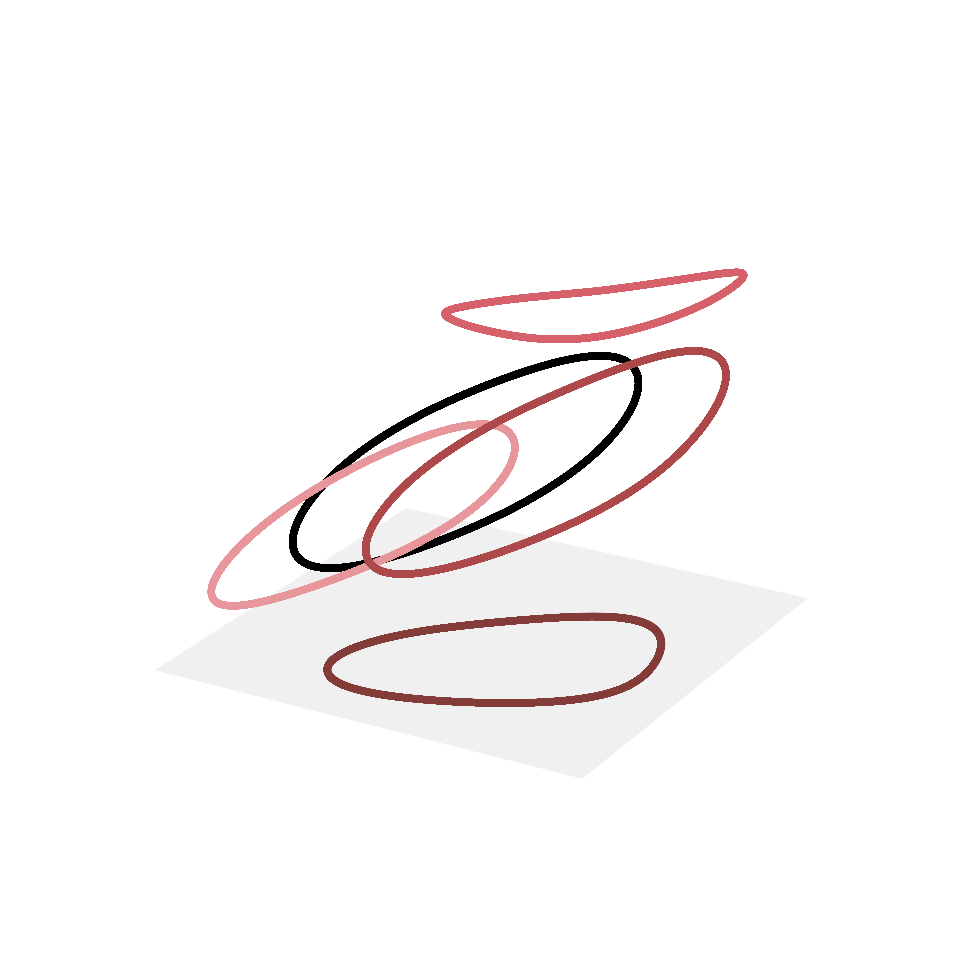

In [18]:
cmap = plt.get_cmap('tab20b')

def cycle_color(k):
    return 'k' if k == 0 else cmap(k + 11)

perm = [0, 1, 4, 3, 2]

def cycle_color_perm(k):
    return cycle_color(perm[k])

fig = plt.figure(figsize=(1,1), dpi=1000)
ax  = fig.add_subplot(111, projection='3d')

for i, (osc, fp) in enumerate(zip(osc_list[:5], fp_list)):
    ax.plot(osc[:,0], osc[:,6], osc[:,36],
            linewidth=0.5, color=cycle_color_perm(i))

ax.view_init(elev=22, azim=-60)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_xlabel(''); ax.set_ylabel(''); ax.set_zlabel('')
ax.tick_params(length=0, width=0)
ax.xaxis.set_pane_color((1,1,1,0))
ax.yaxis.set_pane_color((1,1,1,0))
ax.zaxis.set_pane_color((0.7137, 0.7137, 0.7137, 0.2))
ax.zaxis.pane.fill = True
ax.zaxis.pane.set_edgecolor((1,1,1,0))
ax.zaxis.pane.set_linewidth(0)
ax.grid(False)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis._axinfo['grid']['linewidth'] = 0
    axis._axinfo['grid']['color']     = (1,1,1,0)
ax.xaxis.line.set_alpha(0)
ax.yaxis.line.set_alpha(0)
ax.zaxis.line.set_alpha(0)
plt.show()

In [21]:
# --- Pairwise orbit distances ---
distances = pairwise_orbit_distances_scale_only(osc_list)

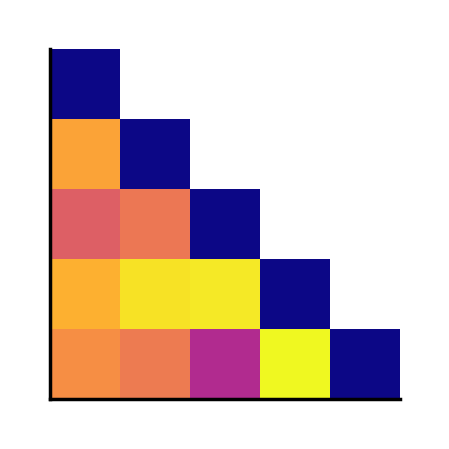

In [22]:
# --- Distance matrix heatmap ---
D = distances['sym_scaled']
K = D.shape[0]
D_plot = D.copy()
D_plot[np.triu(np.ones_like(D, dtype=bool), k=1)] = np.nan

fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
im = ax.imshow(D_plot, cmap='plasma')
ax.set_xticks([]); ax.set_yticks([])
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for s in ax.spines.values(): s.set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2, labelsize=5)
plt.tight_layout()
plt.show()

/var/folders/46/jrxtfx3d13v4tybb9f4_lz300000gn/T/ipykernel_72423/4008600273.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 500x500 with 1 Axes> than <Figure size 25x500 with 1 Axes> which fig.colorbar is called on.
  cbar = fig_cb.colorbar(im, cax=ax_cb)


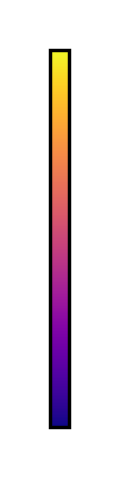

In [23]:
# --- Standalone colorbar ---
fig_cb, ax_cb = plt.subplots(figsize=(0.05, 1), dpi=500)
cbar = fig_cb.colorbar(im, cax=ax_cb)
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(width=0.5, length=2, labelsize=6)
cbar.set_ticks([])
plt.show()